# Experiments Guide

## 0. Colab Setup

In [ ]:
!git clone -b dev-CREMAD https://github.com/luigiaceto/explainable-models-for-speech-analysis.git
%cd explainable-models-for-speech-analysis
%pip install -r requirements-colab.txt

## 1. Project Setup

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.audio_features import pooled_feature_dim
from src.utils.naming import (
    model_name_to_slug
)

# --- data paths ---
DATASET_ID = "crema_d"
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw" / DATASET_ID
AUDIO_DIR = RAW_DIR / "AudioWAV"

# --- feature extraction infos ---
FEATURE_EXTRACTOR = ("microsoft/wavlm-large", 1024) # (model_name, dimension_of_the_original_vectors_generated_by_the_model)
FEATURE_EXTRACTOR_NAME, ENCODER_EMBEDDING_DIM = FEATURE_EXTRACTOR
FEATURE_EXTRACTOR_ID = model_name_to_slug(FEATURE_EXTRACTOR_NAME)
FEATURE_POOLING = "mean_std"
FEATURE_DIM = pooled_feature_dim(ENCODER_EMBEDDING_DIM, FEATURE_POOLING)

#SPLIT_STRATEGY = "sample_stratified"
SPLIT_STRATEGY = "speaker_independent" # each split has different voice actors

# --- output artifacts naming ---
FEATURE_RUN_ID = f"{DATASET_ID}_{FEATURE_EXTRACTOR_ID}_{FEATURE_POOLING}"
BLACK_BOX_RUN_ID = f"blackbox_{DATASET_ID}_{FEATURE_EXTRACTOR_ID}_{SPLIT_STRATEGY}"
BLACK_BOX_EMBEDDING_RUN_ID = f"{BLACK_BOX_RUN_ID}_penultimate_l2"
PROTOTYPE_CLUSTERING_RUN_ID = f"prototype_clustering_{BLACK_BOX_EMBEDDING_RUN_ID}"
FEATURE_DIR = DATA_DIR / "features" / FEATURE_RUN_ID
BLACK_BOX_CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints" / BLACK_BOX_RUN_ID
BLACK_BOX_REPORT_DIR = PROJECT_ROOT / "reports" / BLACK_BOX_RUN_ID
BLACK_BOX_EMBEDDING_DIR = DATA_DIR / "features" / BLACK_BOX_EMBEDDING_RUN_ID
PROTOTYPE_CLUSTERING_CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints" / PROTOTYPE_CLUSTERING_RUN_ID
PROTOTYPE_CLUSTERING_REPORT_DIR = PROJECT_ROOT / "reports" / PROTOTYPE_CLUSTERING_RUN_ID

# --- runtime parameters ---
FEATURE_EXTRACTION_BATCH_SIZE = 8
FEATURE_EXTRACTION_NUM_WORKERS = 0
RANDOM_STATE = 42

PROJECT_ROOT

PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis')

## 2. Download CREMA-D

In [5]:
from src.preprocessing.download_crema_d import download_crema_d

metadata = download_crema_d(
    output_dir=RAW_DIR,
    overwrite=False
)

metadata.head(n=10)

,file_name,actor_id,sentence_code,sentence,emotion_code,emotion,label,intensity_code,intensity,audio_path
0,1001_DFA_ANG_XX.wav,1001,DFA,Don't forget a jacket,ANG,anger,0,XX,unspecified,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
1,1001_DFA_DIS_XX.wav,1001,DFA,Don't forget a jacket,DIS,disgust,1,XX,unspecified,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
2,1001_DFA_FEA_XX.wav,1001,DFA,Don't forget a jacket,FEA,fear,2,XX,unspecified,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
3,1001_DFA_HAP_XX.wav,1001,DFA,Don't forget a jacket,HAP,happy,3,XX,unspecified,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
4,1001_DFA_NEU_XX.wav,1001,DFA,Don't forget a jacket,NEU,neutral,4,XX,unspecified,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
5,1001_DFA_SAD_XX.wav,1001,DFA,Don't forget a jacket,SAD,sad,5,XX,unspecified,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
6,1001_IEO_ANG_HI.wav,1001,IEO,It's eleven o'clock,ANG,anger,0,HI,high,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
7,1001_IEO_ANG_LO.wav,1001,IEO,It's eleven o'clock,ANG,anger,0,LO,low,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
8,1001_IEO_ANG_MD.wav,1001,IEO,It's eleven o'clock,ANG,anger,0,MD,medium,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...
9,1001_IEO_DIS_HI.wav,1001,IEO,It's eleven o'clock,DIS,disgust,1,HI,high,/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/...


## 3. Extract Frozen Audio Encoder Features

In [6]:
from src.preprocessing.extract_audio_features import extract_audio_features

feature_paths = extract_audio_features(
    metadata_csv=RAW_DIR / "metadata.csv",
    audio_dir=AUDIO_DIR,
    output_dir=FEATURE_DIR,
    model_name=FEATURE_EXTRACTOR_NAME,
    expected_encoder_embedding_dim=ENCODER_EMBEDDING_DIM,
    pooling=FEATURE_POOLING,
    batch_size=FEATURE_EXTRACTION_BATCH_SIZE,
    num_workers=FEATURE_EXTRACTION_NUM_WORKERS,
    overwrite=False
)

feature_paths

{'features': PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/data/features/crema_d_wavlm_large_mean_std/features.npy'),
 'metadata': PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/data/features/crema_d_wavlm_large_mean_std/metadata.csv'),
 'config': PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/data/features/crema_d_wavlm_large_mean_std/feature_config.json')}

## 4. Audio Feature Statistics

In [7]:
from src.data.crema_d import load_features, print_dataset_statistics

_, feature_metadata = load_features(FEATURE_DIR, mmap_mode="r")
print_dataset_statistics(feature_metadata)

Total samples: 7442
Actors: 91
Sentence prompts: 12

Samples per emotion:
emotion  sample_count  percentage
  anger          1271   17.078742
disgust          1271   17.078742
   fear          1271   17.078742
  happy          1271   17.078742
neutral          1087   14.606289
    sad          1271   17.078742


## 5. Train the Black-Box Classifier

In [9]:
from src.training.train_blackbox import TrainingConfig, train_blackbox

LAYER_DIMS = (256, 128)

training_config = TrainingConfig(
    input_dim=FEATURE_DIM,
    feature_extractor_name=FEATURE_EXTRACTOR_NAME,
    encoder_embedding_dim=ENCODER_EMBEDDING_DIM,
    pooling=FEATURE_POOLING,
    hidden_dims=LAYER_DIMS,
    batch_size=64,
    epochs=100,
    dropout=0.25,
    learning_rate=2e-4,
    weight_decay=5e-4,
    split_strategy=SPLIT_STRATEGY,
    speaker_column="actor_id",
    early_stopping_patience=15,
    #lr_scheduler=None, # by default the scheduler is active. Need to set it explicitly to None if we wanna turn it off
    scheduler_patience=6,
    random_state=RANDOM_STATE
)

training_results = train_blackbox(
    feature_dir=FEATURE_DIR,
    output_dir=BLACK_BOX_CHECKPOINT_DIR,
    config=training_config
)

/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/src/data/crema_d.py:175: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  self.labels = torch.as_tensor(


Training black-box model:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 001 | train loss 1.5876, acc 0.3436, macro F1 0.3233 | val loss 1.4214, acc 0.4229, macro F1 0.3581, weighted F1 0.3560 | lr 2.00e-04 | best
Epoch 002 | train loss 1.3401, acc 0.4674, macro F1 0.4516 | val loss 1.2586, acc 0.5342, macro F1 0.5287, weighted F1 0.5272 | lr 2.00e-04 | best
Epoch 003 | train loss 1.1982, acc 0.5394, macro F1 0.5310 | val loss 1.1625, acc 0.5464, macro F1 0.5287, weighted F1 0.5271 | lr 2.00e-04 | best
Epoch 004 | train loss 1.0837, acc 0.5852, macro F1 0.5811 | val loss 1.1179, acc 0.5884, macro F1 0.5859, weighted F1 0.5855 | lr 2.00e-04 | best
Epoch 005 | train loss 1.0189, acc 0.6101, macro F1 0.6073 | val loss 1.0188, acc 0.6130, macro F1 0.6127, weighted F1 0.6111 | lr 2.00e-04 | best
Epoch 006 | train loss 0.9679, acc 0.6300, macro F1 0.6280 | val loss 1.0467, acc 0.5858, macro F1 0.5677, weighted F1 0.5647 | lr 2.00e-04 | patience 1/15
Epoch 007 | train loss 0.9256, acc 0.6512, macro F1 0.6497 | val loss 0.9729, acc 0.6322, macro F1 0.6287, we

## 6. Evaluate the Black-Box Classifier

In [10]:
from src.evaluation.evaluate_blackbox import evaluate_blackbox
from src.evaluation.metrics import print_classification_metrics

test_metrics = evaluate_blackbox(
    checkpoint_path=BLACK_BOX_CHECKPOINT_DIR / "best_model.pt",
    feature_dir=FEATURE_DIR,
    splits_csv=BLACK_BOX_CHECKPOINT_DIR / "splits.csv",
    split="test",
    output_dir=BLACK_BOX_REPORT_DIR
)

print_classification_metrics(test_metrics)

Accuracy:    0.7230
Macro F1:    0.7265
Weighted F1: 0.7239

Classification report:
emotion precision recall f1_score  support
  anger    0.8696 0.8163   0.8421      196
disgust    0.6977 0.6122   0.6522      196
   fear    0.7065 0.6633   0.6842      196
  happy    0.6588 0.7092   0.6830      196
neutral    0.8373 0.8274   0.8323      168
    sad    0.6147 0.7245   0.6651      196


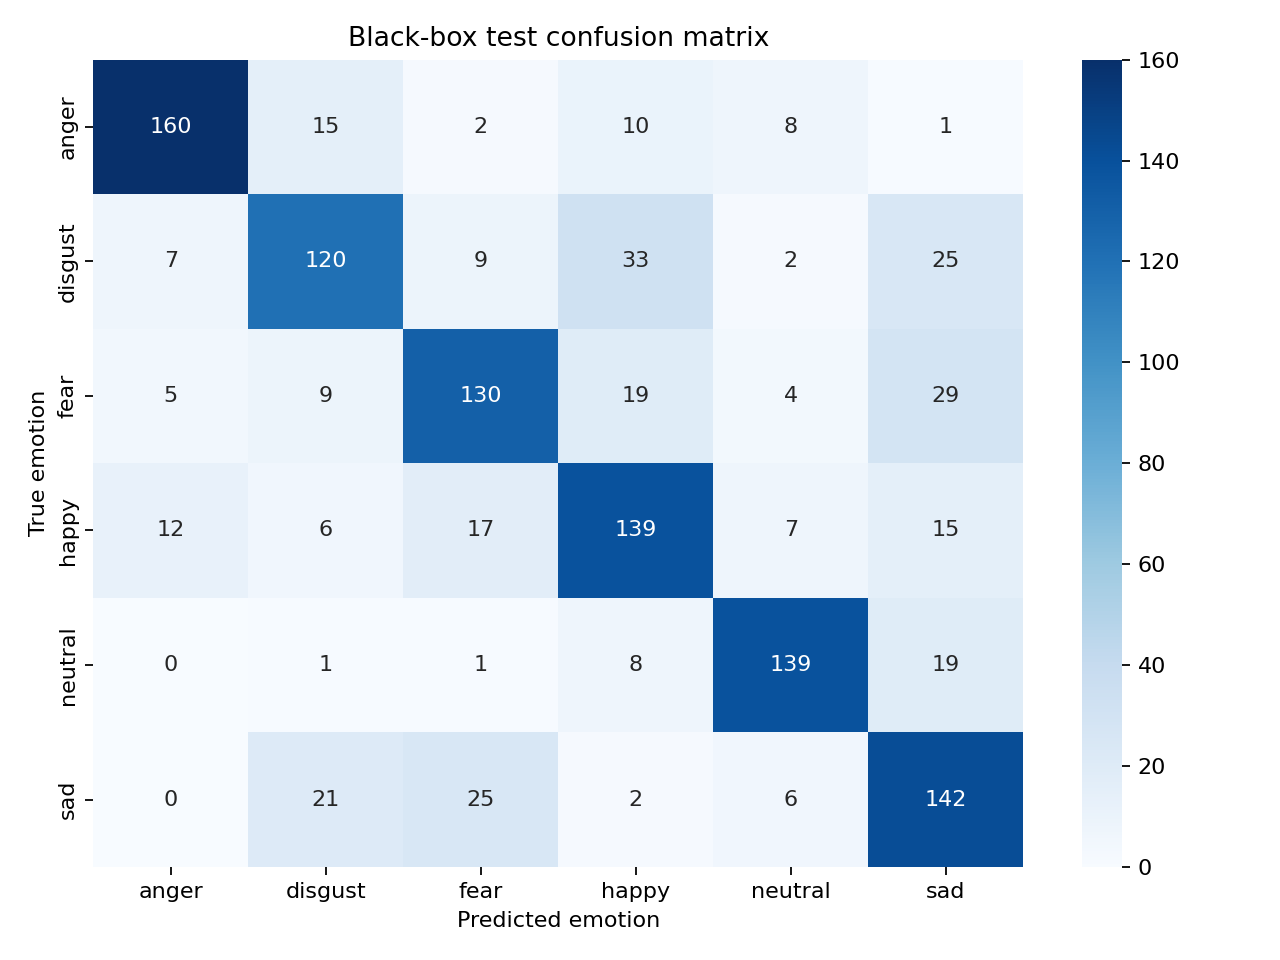

In [11]:
from IPython.display import Image, display

confusion_matrix_path = BLACK_BOX_REPORT_DIR / "test_confusion_matrix.png"
if confusion_matrix_path.exists():
    display(Image(filename=str(confusion_matrix_path)))

## 7. Visualize Embedding Spaces

Project the pooled audio encoder features and the trained black-box penultimate representations to two PCA dimensions.


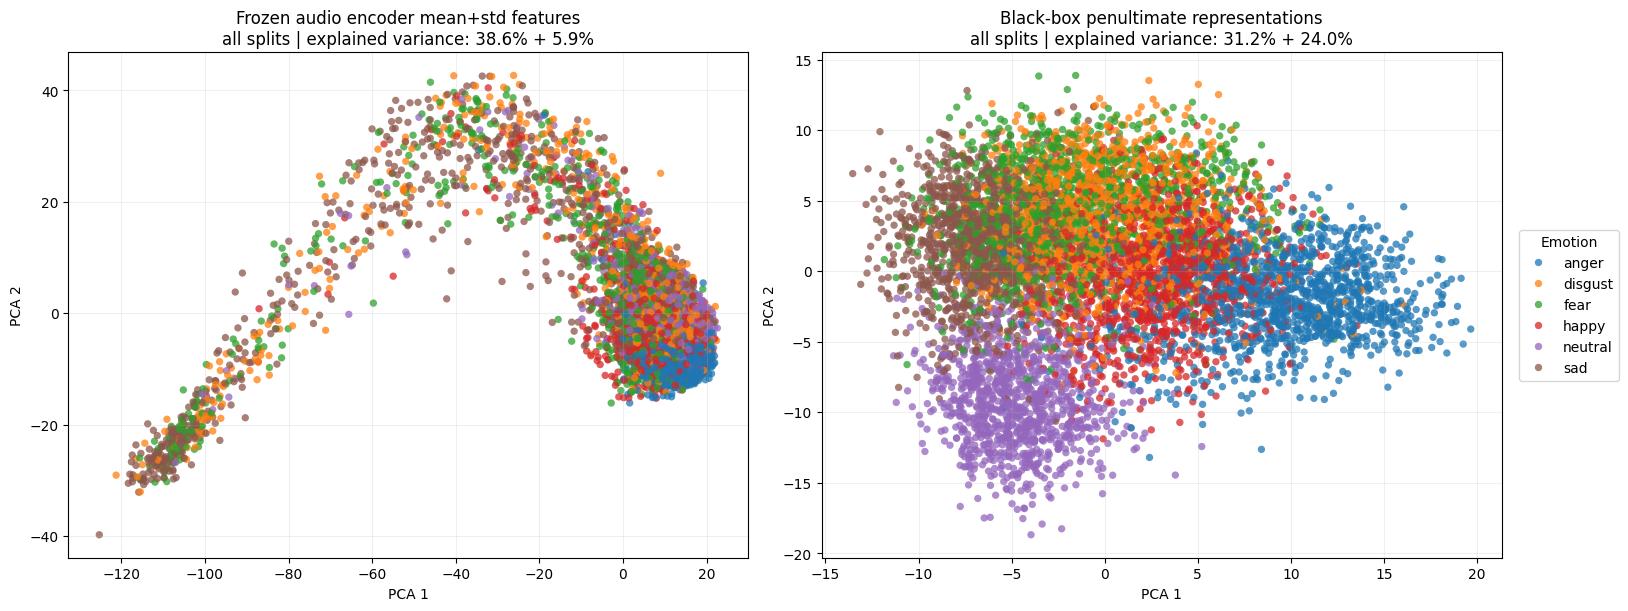

PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/reports/blackbox_crema_d_wavlm_large_speaker_independent/all_embedding_pca.png')

In [12]:
from src.utils.visualize import plot_blackbox_embedding_pca

split_to_visualize = "all"

embedding_pca_result = plot_blackbox_embedding_pca(
    feature_dir=FEATURE_DIR,
    checkpoint_path=BLACK_BOX_CHECKPOINT_DIR / "best_model.pt",
    splits_csv=BLACK_BOX_CHECKPOINT_DIR / "splits.csv",
    split=split_to_visualize,
    output_path=BLACK_BOX_REPORT_DIR / f"{split_to_visualize}_embedding_pca.png",
    random_state=RANDOM_STATE
)

embedding_pca_result["output_path"]

## 8. Extract Black-Box Penultimate Embeddings

Extract the representation before the final black-box classification layer and save its L2-normalized version.

In [13]:
from src.preprocessing.extract_blackbox_embeddings import extract_blackbox_penultimate_embeddings_l2

blackbox_embedding_paths = extract_blackbox_penultimate_embeddings_l2(
    feature_dir=FEATURE_DIR,
    checkpoint_path=BLACK_BOX_CHECKPOINT_DIR / "best_model.pt",
    splits_csv=BLACK_BOX_CHECKPOINT_DIR / "splits.csv",
    output_dir=BLACK_BOX_EMBEDDING_DIR,
    batch_size=256,
    overwrite=False
)

blackbox_embedding_paths

{'features': PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/data/features/blackbox_crema_d_wavlm_large_speaker_independent_penultimate_l2/features.npy'),
 'metadata': PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/data/features/blackbox_crema_d_wavlm_large_speaker_independent_penultimate_l2/metadata.csv'),
 'config': PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/data/features/blackbox_crema_d_wavlm_large_speaker_independent_penultimate_l2/embedding_config.json')}

## 9. Prototype Clustering Grid Search

Fit K-means on the training split only, with K clusters per emotion. Each centroid is mapped to the nearest real training sample of the same emotion, and these real prototypes are used for classification. Select K and top-N on the validation split.

In [14]:
from src.training.train_prototype_clustering import (
    PrototypeClusteringTrainingConfig,
    train_prototype_clustering
)

prototype_training_config = PrototypeClusteringTrainingConfig(
    embedding_dim=LAYER_DIMS[-1],
    cluster_counts=(1, 2, 3, 4, 5, 6),
    monitor_metric="macro_f1",
    random_state=RANDOM_STATE
)

prototype_training_results = train_prototype_clustering(
    embedding_dir=BLACK_BOX_EMBEDDING_DIR,
    output_dir=PROTOTYPE_CLUSTERING_CHECKPOINT_DIR,
    config=prototype_training_config
)

K=01, all prototypes=06 | val acc 0.6961, macro F1 0.6934, weighted F1 0.6905
K=02, all prototypes=12 | val acc 0.6961, macro F1 0.6920, weighted F1 0.6889
K=03, all prototypes=18 | val acc 0.6918, macro F1 0.6854, weighted F1 0.6824
K=04, all prototypes=24 | val acc 0.6848, macro F1 0.6774, weighted F1 0.6742
K=05, all prototypes=30 | val acc 0.6830, macro F1 0.6762, weighted F1 0.6732
K=06, all prototypes=36 | val acc 0.6760, macro F1 0.6667, weighted F1 0.6631

Best prototype clustering configuration
  K:           1
  Prototypes:  6 used for voting
  Validation:  accuracy 0.6961, macro F1 0.6934, weighted F1 0.6905


## 10. Evaluate Prototype Clustering Classifier

In [15]:
from src.evaluation.evaluate_prototype_clustering import evaluate_prototype_clustering
from src.evaluation.metrics import print_classification_metrics

prototype_test_metrics = evaluate_prototype_clustering(
    model_dir=PROTOTYPE_CLUSTERING_CHECKPOINT_DIR,
    embedding_dir=BLACK_BOX_EMBEDDING_DIR,
    split="test",
    output_dir=PROTOTYPE_CLUSTERING_REPORT_DIR
)

print_classification_metrics(prototype_test_metrics)

Accuracy:    0.6838
Macro F1:    0.6827
Weighted F1: 0.6795

Classification report:
emotion precision recall f1_score  support
  anger    0.7824 0.8622   0.8204      196
disgust    0.8065 0.5102   0.6250      196
   fear    0.6306 0.5051   0.5609      196
  happy    0.5639 0.6531   0.6052      196
neutral    0.7921 0.8393   0.8150      168
    sad    0.6016 0.7551   0.6697      196


## 11. Evaluate Prototype Surrogate Fidelity

Measure how often the clustering surrogate matches the black-box predictions on the test split.

In [16]:
from src.explainability.surrogate_fidelity import print_clustering_surrogate_fidelity_accuracy

surrogate_fidelity_metrics = print_clustering_surrogate_fidelity_accuracy(
    blackbox_checkpoint_path=BLACK_BOX_CHECKPOINT_DIR / "best_model.pt",
    feature_dir=FEATURE_DIR,
    prototype_model_dir=PROTOTYPE_CLUSTERING_CHECKPOINT_DIR,
    embedding_dir=BLACK_BOX_EMBEDDING_DIR,
    splits_csv=BLACK_BOX_CHECKPOINT_DIR / "splits.csv",
    split="test"
)

Accuracy against black-box predictions: 0.8563 (983/1148)


## 12. Visualize Prototype Embedding Space

Project the saved L2-normalized black-box embeddings to two PCA dimensions and highlight the prototypes of each emotion.

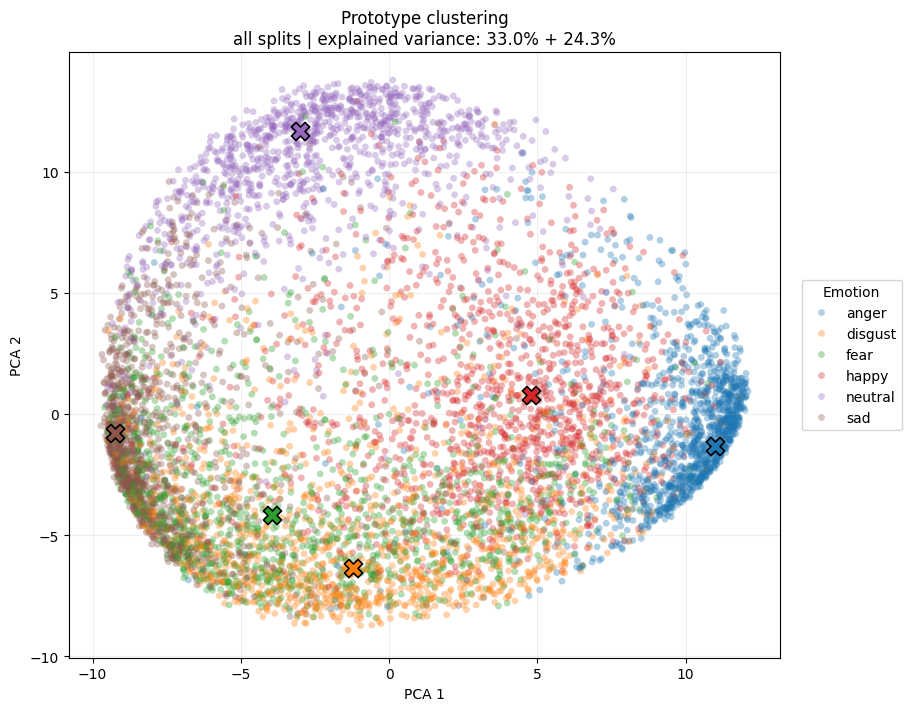

PosixPath('/Users/luigi/Documents/MSc-PoliTO/II_anno/XAI/progetto/explainable-models-for-speech-analysis/reports/prototype_clustering_blackbox_crema_d_wavlm_large_speaker_independent_penultimate_l2/all_prototype_embedding_pca.png')

In [17]:
from src.utils.visualize import plot_prototype_embedding_pca

split_to_visualize = "all"

prototype_pca_result = plot_prototype_embedding_pca(
    embedding_dir=BLACK_BOX_EMBEDDING_DIR,
    model_dir=PROTOTYPE_CLUSTERING_CHECKPOINT_DIR,
    split=split_to_visualize,
    output_path=PROTOTYPE_CLUSTERING_REPORT_DIR / f"{split_to_visualize}_prototype_embedding_pca.png",
    random_state=RANDOM_STATE
)

prototype_pca_result["output_path"]

## 13. Explanation By Example - Inspect Prototype Neighbors of a Test Sample

In [15]:
import pandas as pd
from src.explainability.prototype_neighbors import (
    explain_sample_by_filename,
    print_prototype_explanation
)

# Set a CREMA-D file name here, or leave it as None to choose a random test sample.
SAMPLE_TO_EXPLAIN = None

prototype_explanation = explain_sample_by_filename(
    embedding_metadata=pd.read_csv(BLACK_BOX_EMBEDDING_DIR / "metadata.csv"),
    sample_to_explain=SAMPLE_TO_EXPLAIN,
    model_dir=PROTOTYPE_CLUSTERING_CHECKPOINT_DIR,
    embedding_dir=BLACK_BOX_EMBEDDING_DIR
)

print_prototype_explanation(prototype_explanation)

Sample:    1068_TSI_FEA_XX.wav
True:      fear
Predicted: fear

Class scores:
    anger: 0.1398
  disgust: 0.2273
     fear: 0.8023
    happy: 0.6555
  neutral: 0.4901
      sad: 0.6055

All 6 voting prototypes, sorted by similarity:
  #01    fear | sim 0.8023 | 1003_TAI_FEA_XX.wav
  #02   happy | sim 0.6555 | 1043_WSI_HAP_XX.wav
  #03     sad | sim 0.6055 | 1088_MTI_SAD_XX.wav
  #04 neutral | sim 0.4901 | 1052_ITS_NEU_XX.wav
  #05 disgust | sim 0.2273 | 1004_IWW_DIS_XX.wav
  #06   anger | sim 0.1398 | 1079_ITS_ANG_XX.wav


We can listen to the test sample and its nearest prototypes (medoids).

In [ ]:
from IPython.display import Audio, display, Markdown

explained_file_name = prototype_explanation["file_name"]
display(Markdown(f"### Sample: `{explained_file_name}`"))
display(Audio(filename=str(AUDIO_DIR / explained_file_name)))

display(Markdown("### Top prototypes"))
for prototype in prototype_explanation["top_prototypes"]:
    prototype_file = prototype.get("prototype_file_name")

    display(Markdown(
        f"**#{prototype['rank']} | {prototype['prototype_emotion']} | "
        f"similarity: {prototype['similarity']:.4f}**  \n"
        f"`{prototype_file}`"
    ))
    display(Audio(filename=str(AUDIO_DIR / prototype_file)))